# Checkpoint (Entrega 2) — Identificador de Gargalos e Recomendador de Upgrades de Hardware

**Disciplina:** Inteligência Artificial — Prof. Adolfo Colares — 2026.1

**Equipe:** Daniela Marques Haber Sepeda · Geovanni Rodrigues da Silva · Maria Fernanda Fernandes de Souza Gonçalves · Miguel Peres Lobo

Este notebook apresenta o progresso do projeto para o checkpoint de **18/06**:

1. **Dados coletados** — base de casos históricos estruturada pela equipe;
2. **Primeiros experimentos** — etapa *Retrieve* do ciclo RBC implementada com KNN e etapa *Reuse* com adaptação da solução;
3. **Avaliação inicial** — acurácia do KNN na identificação do gargalo;
4. **Dificuldades encontradas** e próximos passos.

## 1. Dados coletados

A base de casos (`data/base_casos.csv`) foi estruturada pela equipe com **40 casos históricos** de máquinas com problemas de desempenho. Cada caso registra:

- **Configuração:** tipo de máquina, geração da CPU, núcleos, RAM, tipo de armazenamento, GPU;
- **Contexto de uso:** perfil de uso e sintoma principal relatado;
- **Telemetria:** percentuais de uso de CPU, RAM e disco no momento do problema;
- **Diagnóstico:** componente identificado como **gargalo** e a **solução recomendada** que resolveu o caso.

Os casos foram montados a partir de cenários técnicos documentados e da experiência da equipe com manutenção de computadores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

casos = pd.read_csv('../data/base_casos.csv')
print(f'Total de casos na base: {len(casos)}')
casos.head()

Total de casos na base: 40


,id_caso,tipo_maquina,cpu_geracao,nucleos_cpu,ram_gb,tipo_armazenamento,gpu,perfil_uso,sintoma_principal,uso_cpu_pct,uso_ram_pct,uso_disco_pct,gargalo,solucao_recomendada
0,1,notebook,antiga,2,4,HDD,integrada,escritorio,boot_lento,35,70,100,armazenamento,instalar SSD SATA
1,2,notebook,antiga,2,4,HDD,integrada,estudo,travamento_multitarefa,40,95,90,ram,aumentar RAM para 8GB
2,3,desktop,intermediaria,4,8,HDD,integrada,escritorio,boot_lento,30,60,100,armazenamento,instalar SSD NVMe
3,4,desktop,intermediaria,4,8,SSD_SATA,dedicada_baixa,jogos,fps_baixo,55,65,40,gpu,trocar por GPU dedicada intermediaria
4,5,desktop,recente,6,16,SSD_NVMe,dedicada_baixa,jogos,fps_baixo,50,55,30,gpu,trocar por GPU dedicada de alto desempenho


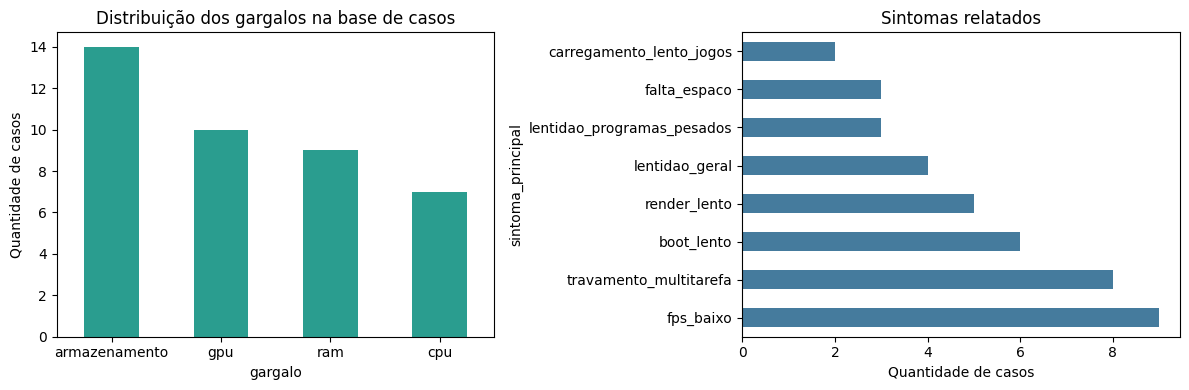

In [2]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

casos['gargalo'].value_counts().plot(kind='bar', ax=eixos[0], color='#2a9d8f')
eixos[0].set_title('Distribuição dos gargalos na base de casos')
eixos[0].set_ylabel('Quantidade de casos')
eixos[0].tick_params(axis='x', rotation=0)

casos['sintoma_principal'].value_counts().plot(kind='barh', ax=eixos[1], color='#457b9d')
eixos[1].set_title('Sintomas relatados')
eixos[1].set_xlabel('Quantidade de casos')

plt.tight_layout()
plt.show()

## 2. Pré-processamento: representando cada caso como vetor numérico

Para o KNN calcular distâncias, todo caso precisa virar um vetor de números:

- Atributos **ordinais** (geração da CPU, tipo de armazenamento, GPU) recebem uma escala que preserva a ordem de desempenho (ex.: HDD = 0 < SSD SATA = 1 < SSD NVMe = 2);
- Atributos **categóricos sem ordem** (tipo de máquina, perfil de uso, sintoma) viram colunas *one-hot*;
- Todos os atributos são normalizados para o intervalo [0, 1] com `MinMaxScaler`, para que nenhuma variável (como RAM em GB) domine o cálculo da distância euclidiana.

In [3]:
from sklearn.preprocessing import MinMaxScaler

MAPA_CPU = {'antiga': 0, 'intermediaria': 1, 'recente': 2}
MAPA_ARMAZENAMENTO = {'HDD': 0, 'SSD_SATA': 1, 'SSD_NVMe': 2}
MAPA_GPU = {'integrada': 0, 'dedicada_baixa': 1, 'dedicada_media': 2, 'dedicada_alta': 3}

CATEGORIAS = {
    'tipo_maquina': ['notebook', 'desktop'],
    'perfil_uso': ['escritorio', 'estudo', 'programacao', 'jogos', 'edicao_video'],
    'sintoma_principal': ['boot_lento', 'travamento_multitarefa', 'fps_baixo', 'render_lento',
                          'lentidao_programas_pesados', 'carregamento_lento_jogos',
                          'lentidao_geral', 'falta_espaco'],
}

ATRIBUTOS = ['tipo_maquina', 'cpu_geracao', 'nucleos_cpu', 'ram_gb', 'tipo_armazenamento',
             'gpu', 'perfil_uso', 'sintoma_principal', 'uso_cpu_pct', 'uso_ram_pct', 'uso_disco_pct']

def vetorizar(df):
    """Converte casos (DataFrame) em vetores numéricos com colunas fixas."""
    x = df[ATRIBUTOS].copy()
    x['cpu_geracao'] = x['cpu_geracao'].map(MAPA_CPU)
    x['tipo_armazenamento'] = x['tipo_armazenamento'].map(MAPA_ARMAZENAMENTO)
    x['gpu'] = x['gpu'].map(MAPA_GPU)
    for coluna, valores in CATEGORIAS.items():
        x[coluna] = pd.Categorical(x[coluna], categories=valores)
    return pd.get_dummies(x, columns=list(CATEGORIAS)).astype(float)

X_bruto = vetorizar(casos)
normalizador = MinMaxScaler().fit(X_bruto)
X = normalizador.transform(X_bruto)

print(f'Matriz de atributos: {X.shape[0]} casos x {X.shape[1]} atributos')
X_bruto.head(3)

Matriz de atributos: 40 casos x 23 atributos


,cpu_geracao,nucleos_cpu,ram_gb,tipo_armazenamento,gpu,uso_cpu_pct,uso_ram_pct,uso_disco_pct,tipo_maquina_notebook,tipo_maquina_desktop,...,perfil_uso_jogos,perfil_uso_edicao_video,sintoma_principal_boot_lento,sintoma_principal_travamento_multitarefa,sintoma_principal_fps_baixo,sintoma_principal_render_lento,sintoma_principal_lentidao_programas_pesados,sintoma_principal_carregamento_lento_jogos,sintoma_principal_lentidao_geral,sintoma_principal_falta_espaco
0,0.0,2.0,4.0,0.0,0.0,35.0,70.0,100.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,2.0,4.0,0.0,0.0,40.0,95.0,90.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,4.0,8.0,0.0,0.0,30.0,60.0,100.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Etapa *Retrieve* — recuperando casos semelhantes com KNN

Dado um caso novo, o KNN calcula a **distância euclidiana** entre ele e todos os casos da base e devolve os *k* vizinhos mais próximos — os casos históricos mais parecidos com a máquina analisada.

In [4]:
from sklearn.neighbors import NearestNeighbors

modelo_knn = NearestNeighbors(n_neighbors=3, metric='euclidean').fit(X)

def recuperar_casos(caso_novo, k=3):
    """Etapa Retrieve: devolve os k casos históricos mais próximos do caso novo."""
    vetor = normalizador.transform(vetorizar(pd.DataFrame([caso_novo])))
    distancias, indices = modelo_knn.kneighbors(vetor, n_neighbors=k)
    semelhantes = casos.iloc[indices[0]].copy()
    semelhantes['distancia'] = distancias[0].round(3)
    return semelhantes

## 4. Etapa *Reuse* — adaptando a solução dos vizinhos

Com os vizinhos recuperados, o sistema identifica o **gargalo mais frequente** entre eles (votação majoritária) e reutiliza a solução do caso mais próximo dentro desse gargalo, apresentando os casos que justificam a recomendação.

In [5]:
def recomendar_upgrade(caso_novo, k=3):
    """Ciclo Retrieve + Reuse: diagnostica o gargalo e recomenda o upgrade."""
    semelhantes = recuperar_casos(caso_novo, k=k)
    gargalo = semelhantes['gargalo'].mode()[0]
    solucao = semelhantes[semelhantes['gargalo'] == gargalo].iloc[0]['solucao_recomendada']

    print(f'Provável gargalo........: {gargalo.upper()}')
    print(f'Upgrade recomendado.....: {solucao}')
    print(f'\nCasos que sustentam a recomendação (k={k}):')
    colunas = ['id_caso', 'tipo_maquina', 'sintoma_principal', 'gargalo', 'solucao_recomendada', 'distancia']
    return semelhantes[colunas].reset_index(drop=True)

In [6]:
# Caso de teste 1: notebook de escritório com HDD e boot muito lento
caso_teste_1 = {
    'tipo_maquina': 'notebook', 'cpu_geracao': 'antiga', 'nucleos_cpu': 2, 'ram_gb': 4,
    'tipo_armazenamento': 'HDD', 'gpu': 'integrada', 'perfil_uso': 'escritorio',
    'sintoma_principal': 'boot_lento', 'uso_cpu_pct': 30, 'uso_ram_pct': 65, 'uso_disco_pct': 100,
}
recomendar_upgrade(caso_teste_1)

Provável gargalo........: ARMAZENAMENTO
Upgrade recomendado.....: instalar SSD SATA

Casos que sustentam a recomendação (k=3):


,id_caso,tipo_maquina,sintoma_principal,gargalo,solucao_recomendada,distancia
0,1,notebook,boot_lento,armazenamento,instalar SSD SATA,0.141
1,33,desktop,boot_lento,armazenamento,instalar SSD SATA,1.467
2,12,notebook,boot_lento,armazenamento,instalar SSD SATA,1.543


In [7]:
# Caso de teste 2: desktop gamer com SSD e FPS baixo em jogos
caso_teste_2 = {
    'tipo_maquina': 'desktop', 'cpu_geracao': 'intermediaria', 'nucleos_cpu': 6, 'ram_gb': 16,
    'tipo_armazenamento': 'SSD_NVMe', 'gpu': 'dedicada_baixa', 'perfil_uso': 'jogos',
    'sintoma_principal': 'fps_baixo', 'uso_cpu_pct': 55, 'uso_ram_pct': 60, 'uso_disco_pct': 30,
}
recomendar_upgrade(caso_teste_2)

Provável gargalo........: GPU
Upgrade recomendado.....: trocar por GPU dedicada de alto desempenho

Casos que sustentam a recomendação (k=3):


,id_caso,tipo_maquina,sintoma_principal,gargalo,solucao_recomendada,distancia
0,5,desktop,fps_baixo,gpu,trocar por GPU dedicada de alto desempenho,0.520
1,25,desktop,fps_baixo,gpu,trocar por GPU dedicada de alto desempenho,0.621
2,35,desktop,fps_baixo,gpu,trocar por GPU dedicada intermediaria,0.680


## 5. Avaliação inicial

Como a base ainda é pequena (40 casos), usamos **validação leave-one-out**: cada caso é retirado da base, o KNN tenta identificar o gargalo dele usando os 39 restantes, e comparamos com o diagnóstico real.

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix

y = casos['gargalo']
classificador = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
previsoes = cross_val_predict(classificador, X, y, cv=LeaveOneOut())

print(f'Acurácia (leave-one-out, k=3): {accuracy_score(y, previsoes):.1%}\n')

rotulos = sorted(y.unique())
matriz = confusion_matrix(y, previsoes, labels=rotulos)
print('Matriz de confusão (linhas = real, colunas = previsto):')
pd.DataFrame(matriz, index=rotulos, columns=rotulos)

Acurácia (leave-one-out, k=3): 80.0%

Matriz de confusão (linhas = real, colunas = previsto):


,armazenamento,cpu,gpu,ram
armazenamento,13,0,1,0
cpu,0,4,3,0
gpu,1,1,8,0
ram,1,1,0,7


In [9]:
# Sensibilidade ao valor de k: qual quantidade de vizinhos funciona melhor?
for k in [1, 3, 5, 7]:
    p = cross_val_predict(KNeighborsClassifier(n_neighbors=k, metric='euclidean'), X, y, cv=LeaveOneOut())
    print(f'k={k}: acurácia = {accuracy_score(y, p):.1%}')

k=1: acurácia = 87.5%


k=3: acurácia = 80.0%


k=5: acurácia = 80.0%


k=7: acurácia = 72.5%


## 6. Dificuldades encontradas

1. **Não existe dataset público pronto** para o problema — foi necessário estruturar a base de casos manualmente, o que limita o tamanho atual (40 casos) e exige cuidado para não enviesar os diagnósticos;
2. **Codificação dos atributos mistos**: equilibrar atributos ordinais (geração de CPU, armazenamento), categóricos (sintoma, perfil de uso) e numéricos (percentuais de uso) na mesma métrica de distância exigiu normalização e testes;
3. **Classes desbalanceadas**: gargalos de armazenamento são mais frequentes na base do que os demais, o que pode favorecer essa classe na votação do KNN;
4. **Adaptação da solução (Reuse)** ainda é simples — hoje reutilizamos a solução do vizinho mais próximo; adaptar a recomendação à configuração exata da máquina (ex.: compatibilidade de socket/slot) é o próximo desafio.

## Próximos passos (até a entrega final de 09/07)

- Ampliar a base de casos e balancear as classes de gargalo;
- Implementar **pesos por atributo** na distância (sintoma deve pesar mais que, por ex., tipo de máquina);
- Completar o ciclo RBC com as etapas **Revise** (validação da recomendação) e **Retain** (inserção do novo caso resolvido na base);
- Construir a **interface da demo** (Google Colab interativo ou Streamlit) para a apresentação final;
- Escrever o relatório técnico.